# Tablero

la representacion mas basica del tablero es self.tablero:

In [65]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [66]:
class Tablero:
    def __init__(self, rows, columns):
        self.rows = rows
        self.columns = columns
        self.tablero = np.ones((rows, columns), dtype=int)

        self.start_pos = []
        self.finish_pos = []

    def generar_curva(self, puntos_intermedios=1, ancho=2):
        start = (self.rows - 1, random.randint(0, self.columns - 1))
        finish = (random.randint(0, self.rows - 1), self.columns - 1)

        puntos_intermedios = [
            (random.randint(0, self.rows - 1), random.randint(0, self.columns - 1)) for _ in range(puntos_intermedios)
        ]

        puntos = [start] + puntos_intermedios + [finish]

        for i in range(len(puntos) - 1):
            x1, y1 = puntos[i]
            x2, y2 = puntos[i + 1]

            # Definimos el vector director
            v_x = x2 - x1
            v_y = y2 - y1

            num_steps = max(abs(x2 - x1), abs(y2 - y1))

            for step in range(num_steps + 1):

                alfa = step / num_steps

                x = int(x1 + alfa * (v_x))
                y = int(y1 + alfa * (v_y))
                
                for dx in range(-ancho, ancho + 1):
                    for dy in range(-ancho, ancho + 1):
                        if 0 <= x + dx < self.rows and 0 <= y + dy < self.columns:
                            self.tablero[x + dx, y + dy] = 0


        for i in range(-ancho, ancho + 1):

            if 0 <= start[1] + i < self.columns:
                posible_start_pos = (start[0], start[1] + i)
                if self.tablero[posible_start_pos] == 0:
                    self.tablero[posible_start_pos] = 2
                    self.start_pos.append(posible_start_pos)

            if 0 <= finish[0] + i < self.rows:
                posible_finish_pos = (finish[0] + i, finish[1])
                if self.tablero[posible_finish_pos] == 0:
                    self.tablero[posible_finish_pos] = 3
                    self.finish_pos.append(posible_finish_pos)


    # mejorar el dibujado.
    def dibujar(self):
        colores = {
            0: (0, 0, 0),       
            1: (255, 255, 255),
            2: (255, 0, 0),   
            3: (0, 255, 0),
        }

        img = np.zeros((self.rows, self.columns, 3), dtype=np.uint8)
        for i in range(self.rows):
            for j in range(self.columns):
                img[i, j] = colores[self.tablero[i, j]]

        plt.axis('off')

        plt.imshow(img)
        plt.show()

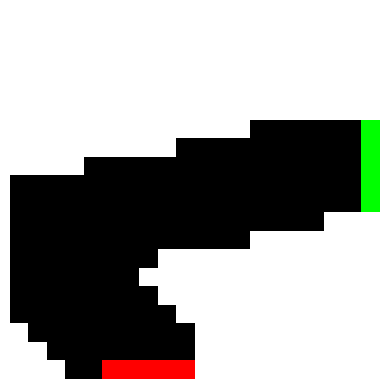

In [67]:
t1 = Tablero(20, 20)
t1.generar_curva()
t1.dibujar()

In [68]:
class State:
    def __init__(self, position, velocity):
        self.position = position
        self.velocity = velocity

    def next_pos(self):
        new_x = self.position[0] + self.velocity[0]
        new_y = self.position[1] + self.velocity[1]
        return (new_x, new_y)
    
    def __repr__(self):
        return f"Pos: {self.position}, Vel: {self.velocity}"

In [69]:
s0 = State((1, 1), (1, 2))
print(s0)
print(s0.next_pos())

Pos: (1, 1), Vel: (1, 2)
(2, 3)


Una accion viene dada por el vector aceleracion (dy, dx). (0, 0), (-1, 1) etc

In [70]:
from abc import ABC, abstractmethod

@abstractmethod
class Agent(ABC):
    def __init__(self):
        self.state = None

    def reset_to_start(self, tablero : Tablero):
        start_pos = random.choice(tablero.start_pos)
        self.state = State(start_pos, (0, 0))

    def update_state(self, action):
        new_vx = self.state.velocity[0] + action[0]
        new_vy = self.state.velocity[1] + action[1]
        new_x = self.state.position[0] + new_vx
        new_y = self.state.position[1] + new_vy

        self.state = State((new_x, new_y), (new_vx, new_vy))

    # listamos las acciones que no suban tu velocidad por encima de lo permitido [-5, 5]
    def posible_actions(self):
        actions = []
        
        for ax in [-1, 0, 1]:
            for ay in [-1, 0, 1]:
                new_vx = self.state.velocity[0] + ax
                new_vy = self.state.velocity[1] + ay
                # Velocidad en [-5, 5] (intervalo cerrado) pero no ambas 0
                if (-5 <= new_vx <= 5) and (-5 <= new_vy <= 5) and not (new_vx == 0 and new_vy == 0):
                    actions.append((ax, ay))
        return actions
                    

    @abstractmethod
    def generate_response(self):
        return

In [71]:
class RandomAgent(Agent):
    def generate_response(self):

        actions = self.posible_actions()
        action = random.choice(actions)
        self.update_state(action)
        return action

In [72]:
class Traza:
    def __init__(self, discount = 0.9):
        self.discount = discount
        self.traza = []

    def append(self, tupla_traza):
        self.traza.append(tupla_traza)
    
    def __len__(self):
        return len(self.traza)
    
    def __get_reward_from_traza(self, traza, discount=True):
        total = 0
        for i, tupla in enumerate(traza):
            r = tupla[2]
            if discount:
                total += r * (self.discount ** i)
            else:
                total += r
        return total
    
    def get_total_reward(self, discount=True):
        return self.__get_reward_from_traza(self.traza, discount)
    
    def get_reward_from_state(self, i_stage, discount=True):
        return self.__get_reward_from_traza(self.traza[i_stage:], discount)
    
    def __repr__(self):
        return str(self.traza)

In [73]:
class Game:
    def __init__(self, tablero : Tablero):
        self.tablero = tablero

    def simulate_episode(self, agente : Agent, max_states=200):
        traza = Traza(discount=0.9)
        
        def agent_is_crash():
            pos_agente = agente.state.position
            
            # Se ha salido del tablero
            if not(0 <= pos_agente[0] < self.tablero.rows and 0 <= pos_agente[1] < self.tablero.columns):
                return True
            
            # Ha chocado con una pared (1 = muro en el tablero)
            if self.tablero.tablero[pos_agente] == 1:
                return True
            
            return False
            
        def agent_is_goal():
            pos_agente = agente.state.position
            # Verificar que la posición es válida antes de acceder
            if not(0 <= pos_agente[0] < self.tablero.rows and 0 <= pos_agente[1] < self.tablero.columns):
                return False
            # Meta = 3
            if self.tablero.tablero[pos_agente] == 3:
                return True
            return False
        
        # Definimos la casilla de salida
        agente.reset_to_start(self.tablero)

        for step in range(max_states):
            # Guardamos el estado ANTES de la acción
            estado_antes = agente.state
            
            # Generamos la accion del agente (esto actualiza el estado)
            action = agente.generate_response()

            tupla_traza = [
                estado_antes,  # Estado antes de la acción
                action,
                -1  # Penalización por paso para incentivar llegar rápido
            ]

            # comprobacion de meta (primero para dar prioridad a la meta)
            if agent_is_goal():
                tupla_traza[2] = 100  # Recompensa alta por llegar
                traza.append(tupla_traza)
                break

            # Comprobacion de crash
            if agent_is_crash():
                tupla_traza[2] = -10  # Penalización por crash
                agente.reset_to_start(self.tablero)

            traza.append(tupla_traza)

        return traza

In [74]:
from abc import ABC, abstractmethod

@abstractmethod
class Agent(ABC):
    def __init__(self):
        self.state = None

    def reset_to_start(self, tablero : Tablero):
        start_pos = random.choice(tablero.start_pos)
        self.state = State(start_pos, (0, 0))

    def update_state(self, action):
        new_vx = self.state.velocity[0] + action[0]
        new_vy = self.state.velocity[1] + action[1]
        new_x = self.state.position[0] + new_vx
        new_y = self.state.position[1] + new_vy

        self.state = State((new_x, new_y), (new_vx, new_vy))

    # listamos las acciones que no suban tu velocidad por encima de lo permitido [-5, 5]
    def posible_actions(self):
        actions = []
        
        for ax in [-1, 0, 1]:
            for ay in [-1, 0, 1]:
                new_vx = self.state.velocity[0] + ax
                new_vy = self.state.velocity[1] + ay
                # Velocidad en [-5, 5] (intervalo cerrado) pero no ambas 0
                if (-5 <= new_vx <= 5) and (-5 <= new_vy <= 5) and not (new_vx == 0 and new_vy == 0):
                    actions.append((ax, ay))
        return actions
                    

    @abstractmethod
    def generate_response(self):
        return

In [75]:
class Q_table:
    def __init__(self, rows, cols, q_inicial=-50):
        # Velocidades van de -5 a 5 (11 valores), acciones de -1 a 1 (3 valores)
        # Shape: (rows, cols, 11 velocidades_x, 11 velocidades_y, 3 acciones_x, 3 acciones_y)
        self.Q_table = np.full((rows, cols, 11, 11, 3, 3), q_inicial, dtype=float)
        self.value_action_pair_count = np.zeros_like(self.Q_table)

    def _vel_to_idx(self, v):
        """Mapea velocidad [-5, 5] a índice [0, 10]"""
        return v + 5

    def update_Q_table(self, pos, speed, action, retorno_s):
        p1, p2 = pos
        v1, v2 = self._vel_to_idx(speed[0]), self._vel_to_idx(speed[1])
        a1, a2 = action[0] + 1, action[1] + 1  # Mapear [-1,0,1] -> [0,1,2]

        self.value_action_pair_count[p1, p2, v1, v2, a1, a2] += 1
        c = self.value_action_pair_count[p1, p2, v1, v2, a1, a2]

        q_value = self.Q_table[p1, p2, v1, v2, a1, a2]
        self.Q_table[p1, p2, v1, v2, a1, a2] += (1 / c) * (retorno_s - q_value)

    def _valid_action_for_state(self, speed, action):
        new_vx = speed[0] + action[0]
        new_vy = speed[1] + action[1]
        # Velocidad en [-5, 5] (intervalo cerrado) pero no ambas 0
        if (-5 <= new_vx <= 5) and (-5 <= new_vy <= 5) and not (new_vx == 0 and new_vy == 0):
            return True
        return False

    def _max_q_policy(self, pos, speed):
        v1, v2 = self._vel_to_idx(speed[0]), self._vel_to_idx(speed[1])
        Q_slice = self.Q_table[pos[0], pos[1], v1, v2, :, :]

        best_action = None
        best_Q_value = -np.inf

        for i in range(3):
            for j in range(3):
                a_i = i - 1  # Mapear [0,1,2] -> [-1,0,1]
                a_j = j - 1

                if self._valid_action_for_state(speed, (a_i, a_j)):
                    Q_value = Q_slice[i, j]
                    if Q_value > best_Q_value:
                        best_action = (a_i, a_j)
                        best_Q_value = Q_value
        
        return best_action
        
    def eps_soft_policy(self, pos, speed, eps):
        if random.random() < eps:
            actions = [(a1, a2) for a1 in [-1, 0, 1] for a2 in [-1, 0, 1] if self._valid_action_for_state(speed, (a1, a2))]
            return random.choice(actions)
        else:
            return self._max_q_policy(pos, speed)

In [76]:
class Eps_soft_policy_agent(Agent):
    def __init__(self, eps, n_rows, n_cols):
        super().__init__()
        self.eps = eps
        self.Q_table = Q_table(n_rows, n_cols)
        self.explore = True

    def generate_response(self):
        if self.explore:
            action = self.Q_table.eps_soft_policy(self.state.position, self.state.velocity, self.eps)
        else:
            action = self.Q_table._max_q_policy(self.state.position, self.state.velocity)
        
        self.update_state(action)
        return action

In [77]:
# Crear agente con Q-table inicializada pesimistamente
off_model_agent = Eps_soft_policy_agent(0.2, t1.rows, t1.columns)  # Más exploración inicial

In [78]:
# Entrenamiento con Off-policy Monte Carlo
num_episodes = 100000
discount = 0.7

game = Game(t1)
goals_reached = 0
best_steps = float('inf')

for episode in range(num_episodes):
    # Simular episodio
    traza = game.simulate_episode(off_model_agent, max_states=200)
    
    # Verificar si llegó a meta
    if len(traza.traza) > 0 and traza.traza[-1][2] == 100:
        goals_reached += 1
        if len(traza.traza) < best_steps:
            best_steps = len(traza.traza)
    
    # Actualizar Q-table con Monte Carlo off-policy
    G = 0
    for i in range(len(traza.traza) - 1, -1, -1):
        state, action, reward = traza.traza[i]
        G = discount * G + reward
        
        # Actualizar Q-table
        off_model_agent.Q_table.update_Q_table(
            state.position,
            state.velocity,
            action,
            G
        )
    
    # Imprimir progreso cada 10000 episodios|
    if (episode + 1) % 10000 == 0:
        print(f"Episodio {episode + 1}/{num_episodes} | Metas: {goals_reached} | Mejor: {best_steps} pasos")

print(f"Mejor trayectoria: {best_steps} pasos")

Episodio 10000/100000 | Metas: 9910 | Mejor: 7 pasos
Episodio 20000/100000 | Metas: 19910 | Mejor: 7 pasos
Episodio 30000/100000 | Metas: 29910 | Mejor: 7 pasos
Episodio 40000/100000 | Metas: 39910 | Mejor: 7 pasos
Episodio 50000/100000 | Metas: 49910 | Mejor: 7 pasos
Episodio 60000/100000 | Metas: 59910 | Mejor: 7 pasos
Episodio 70000/100000 | Metas: 69910 | Mejor: 7 pasos
Episodio 80000/100000 | Metas: 79910 | Mejor: 7 pasos
Episodio 90000/100000 | Metas: 89910 | Mejor: 7 pasos
Episodio 100000/100000 | Metas: 99910 | Mejor: 7 pasos
Mejor trayectoria: 7 pasos


In [79]:
# traza final del agente entrenado
off_model_agent.explore = False  # Desactivar exploración para evaluación
final_traza = game.simulate_episode(off_model_agent, max_states=200)
off_model_agent.explore = True  # Reactivar exploración si se desea seguir entrenando

print("Traza final del agente entrenado:")
for step, (state, action, reward) in enumerate(final_traza.traza):
    print(f"Paso {step + 1}: Estado: {state}, Acción: {action}, Recompensa: {reward}")

Traza final del agente entrenado:
Paso 1: Estado: Pos: (19, 9), Vel: (0, 0), Acción: (-1, -1), Recompensa: -1
Paso 2: Estado: Pos: (18, 8), Vel: (-1, -1), Acción: (1, 0), Recompensa: -1
Paso 3: Estado: Pos: (18, 7), Vel: (0, -1), Acción: (-1, 0), Recompensa: -1
Paso 4: Estado: Pos: (17, 6), Vel: (-1, -1), Acción: (-1, 1), Recompensa: -1
Paso 5: Estado: Pos: (15, 6), Vel: (-2, 0), Acción: (0, 1), Recompensa: -1
Paso 6: Estado: Pos: (13, 7), Vel: (-2, 1), Acción: (1, 1), Recompensa: -1
Paso 7: Estado: Pos: (12, 9), Vel: (-1, 2), Acción: (0, 1), Recompensa: -1
Paso 8: Estado: Pos: (11, 12), Vel: (-1, 3), Acción: (0, 0), Recompensa: -1
Paso 9: Estado: Pos: (10, 15), Vel: (-1, 3), Acción: (-1, 1), Recompensa: 100


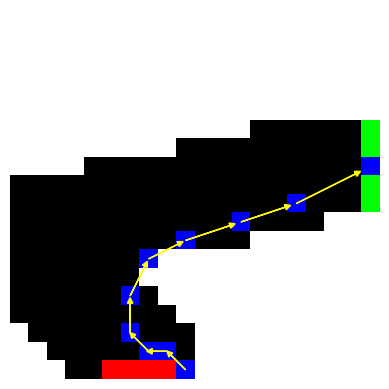

In [93]:
img = t1.tablero.copy()
posiciones_coche = [step[0].position for step in final_traza.traza] + [off_model_agent.state.position]


for pos in posiciones_coche:
    img[pos] = 4  # Marcamos la posición del coche en la traza con un valor distinto
colores = {
    0: (0, 0, 0),
    1: (255, 255, 255),
    2: (255, 0, 0),
    3: (0, 255, 0),
    4: (0, 0, 255)  # Azul para la traza del coche
}

plt.axis('off')
img_rgb = np.zeros((t1.rows, t1.columns, 3), dtype=np.uint8)
for i in range(t1.rows):
    for j in range(t1.columns):
        img_rgb[i, j] = colores[img[i, j]]
plt.imshow(img_rgb)

#ploteamos flechas para la traza del coche
for step in final_traza.traza[:]:
    state = step[0]
    ac = step[1]
    pos = state.position
    vel = [state.velocity[0] + ac[0], state.velocity[1] + ac[1]] 
    plt.arrow(pos[1], pos[0], vel[1]*0.8, vel[0]*0.8, head_width=0.3, head_length=0.3, fc='yellow', ec='yellow')
plt.show()

